# Detectability Diagnostics

This notebook compares non-defense detectability signals against attack
effectiveness for every paper value selector. It distinguishes dataset,
poison rate, sampling strategy, and target-feature policy.

Current artifact diagnostics are preferred over historical aggregate
tables. The current experiment matrix contains 1%, 3%, and 5% poisoning
under random and distribution-based sampling.

In [1]:
from pathlib import Path
import os
import sys

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RESULTS_ROOT = PROJECT_ROOT / "results" / "experiment 1"
MPLCONFIGDIR = PROJECT_ROOT / "build" / "matplotlib"
MPLCONFIGDIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(MPLCONFIGDIR))

import matplotlib.pyplot as plt
import seaborn as sns

from src.analysis.result_catalog import (
    DEFENSE_LABELS,
    DEFENSE_METHOD_ORDER,
    PMSB_SAMPLING_STRATEGIES,
    SAMPLING_ORDER,
    VALUE_LABELS,
    VALUE_ORDER,
    add_display_columns,
    comparison_coverage,
    discover_attack_artifacts,
    load_attack_summaries,
    load_detector_metrics,
    load_defense_metrics,
    load_detectability_score_metrics,
    load_detectability_summaries,
    merge_effectiveness,
    preferred_detector_metrics,
    preferred_defense_metrics,
)

pd.set_option("display.max_rows", 300)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 220)
sns.set_theme(style="whitegrid", context="notebook")

PAPER_VALUE_SELECTORS = [
    "combined_shap",
    "argmin_Nv_sum_abs_shap",
    "min_population_new",
    "low_shap_signed",
    "frequency_bounded",
    "frequency_bounded_signed_shap",
    "quantile_05",
    "quantile_50",
    "quantile_95",
    "benign_prototype",
    "corr_count_abs_shap",
]
PAPER_SAMPLINGS = ["random", "distribution_based_distance"]
PAPER_TARGET_FEATURES = ["problem_space_conservative"]
FOCUS_DATASETS = ["EMBER2018", "EMBER2024 WIN64"]
FOCUS_POISON_RATES = [0.01, 0.03, 0.05]

print("Project root:", PROJECT_ROOT)
print("Results root:", RESULTS_ROOT)

Project root: /Users/falcon/Machine Learning/Defense GMM-Maha
Results root: /Users/falcon/Machine Learning/Defense GMM-Maha/results


## Analysis Controls

In [2]:
def filter_paper_rows(df):
    if df.empty:
        return df.copy()
    out = df[
        df["dataset_label"].isin(FOCUS_DATASETS)
        & df["sampling_strategy"].isin(PAPER_SAMPLINGS)
        & df["value_selector"].isin(PAPER_VALUE_SELECTORS)
        & df["target_features"].isin(PAPER_TARGET_FEATURES)
    ].copy()
    if FOCUS_POISON_RATES is not None:
        wanted = np.asarray(FOCUS_POISON_RATES, dtype=float)
        out = out[
            out["poison_rate_train"].map(
                lambda value: np.isclose(value, wanted, atol=1e-12).any()
                if pd.notna(value)
                else False
            )
        ]
    return add_display_columns(out)


def ensure_footprint_columns(df):
    if df.empty:
        return df.copy()
    out = df.copy()
    eps = 1e-12
    for tag in ["025p", "050p", "075p", "100p"]:
        freq_col = f"joint_threshold_{tag}_clean_frequency"
        neg_col = f"joint_threshold_{tag}_clean_neg_log10_frequency"
        poison_col = f"joint_threshold_{tag}_poisoned_frequency"
        ratio_col = f"joint_threshold_{tag}_poison_only_support_ratio"
        if freq_col in out.columns and neg_col not in out.columns:
            freq = pd.to_numeric(out[freq_col], errors="coerce")
            out[neg_col] = -np.log10(freq.clip(lower=eps, upper=1.0))
        if freq_col in out.columns and poison_col in out.columns and ratio_col not in out.columns:
            freq = pd.to_numeric(out[freq_col], errors="coerce")
            poison = pd.to_numeric(out[poison_col], errors="coerce")
            out[ratio_col] = poison / freq.clip(lower=eps)
    return out


def ordered_pivot(df, *, index, columns, values, aggfunc="mean"):
    pivot = df.pivot_table(
        index=index,
        columns=columns,
        values=values,
        aggfunc=aggfunc,
        observed=True,
    )
    if columns in {"value_selector", "selector_label"}:
        labels = [VALUE_LABELS[value] for value in PAPER_VALUE_SELECTORS]
        pivot = pivot.reindex(columns=[label for label in labels if label in pivot.columns])
    return pivot.dropna(how="all", axis=0).dropna(how="all", axis=1)


def show_heatmap(pivot, title, *, cmap="viridis", fmt=".1f", center=None, vmin=None, vmax=None):
    if pivot.empty:
        print("No rows for", title)
        return
    width = max(9, 0.82 * pivot.shape[1] + 2.5)
    height = max(3.2, 0.55 * pivot.shape[0] + 2.0)
    fig, ax = plt.subplots(figsize=(width, height))
    sns.heatmap(
        pivot,
        annot=True,
        fmt=fmt,
        cmap=cmap,
        center=center,
        vmin=vmin,
        vmax=vmax,
        linewidths=0.5,
        linecolor="white",
        ax=ax,
    )
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    plt.tight_layout()
    plt.show()

## Load Effectiveness, Artifacts, And Diagnostics

In [3]:
attack_df_all = load_attack_summaries(RESULTS_ROOT)
artifact_df_all = discover_attack_artifacts(RESULTS_ROOT)
diagnostic_df_all = load_detectability_summaries(
    RESULTS_ROOT, include_legacy_aggregate=True
)
score_df_all = load_detectability_score_metrics(
    RESULTS_ROOT, include_legacy_aggregate=True
)

attack_df = filter_paper_rows(attack_df_all)
artifact_df = filter_paper_rows(artifact_df_all)
diagnostic_df = ensure_footprint_columns(filter_paper_rows(diagnostic_df_all))
score_df = filter_paper_rows(score_df_all)
merged_df = ensure_footprint_columns(merge_effectiveness(diagnostic_df, attack_df))

print("Attack rows:", len(attack_df))
print("Attack artifact records:", len(artifact_df))
print("Diagnostics-ready artifacts:", int(artifact_df["diagnostics_ready"].sum()))
print("Diagnostic summaries:", len(diagnostic_df))
print("Diagnostic score rows:", len(score_df))
if not diagnostic_df.empty:
    display(
        diagnostic_df.groupby(
            ["dataset_label", "poison_rate_label", "sampling_strategy", "diagnostic_source"],
            dropna=False,
        )
        .size()
        .rename("rows")
        .reset_index()
    )

Attack rows: 152
Attack artifact records: 132
Diagnostics-ready artifacts: 11
Diagnostic summaries: 44
Diagnostic score rows: 1267


,dataset_label,poison_rate_label,sampling_strategy,diagnostic_source,rows
0,EMBER2018,1%,distribution_based_distance,current_artifact,11
1,EMBER2018,1%,random,current_artifact,11
2,EMBER2024 WIN64,1%,distribution_based_distance,current_artifact,11
3,EMBER2024 WIN64,1%,random,current_artifact,11


## Coverage And Missing Diagnostics

`artifact_available=True` means diagnostics can be generated directly
with the existing files. Summary-only runs still need
`--save-attack-artifacts --save-defense-inputs` before diagnostics can be
computed.

In [4]:
attack_coverage = comparison_coverage(
    attack_df,
    datasets=FOCUS_DATASETS,
    samplings=PAPER_SAMPLINGS,
    target_features=PAPER_TARGET_FEATURES,
)
display(attack_coverage)

keys = [
    "dataset_label",
    "sampling_strategy",
    "poison_rate_train",
    "feature_selector",
    "value_selector",
    "target_features",
]
available = artifact_df[
    artifact_df["diagnostics_ready"]
][keys + ["artifact_dir"]].drop_duplicates(keys)
artifact_status = artifact_df[
    keys + ["diagnostics_ready", "missing_diagnostic_files"]
].drop_duplicates(keys)
completed = diagnostic_df[keys + ["diagnostic_source"]].drop_duplicates(keys)
missing_diagnostics = (
    attack_df[keys + ["poison_rate_label", "summary_df_path"]]
    .drop_duplicates(keys)
    .merge(artifact_status, on=keys, how="left")
    .merge(available, on=keys, how="left")
    .merge(completed, on=keys, how="left")
)
missing_diagnostics["artifact_available"] = missing_diagnostics["artifact_dir"].notna()
missing_diagnostics = missing_diagnostics[
    missing_diagnostics["diagnostic_source"].isna()
].sort_values(["dataset_label", "poison_rate_train", "sampling_strategy", "value_selector"])

print("Attack configurations without matching diagnostics:", len(missing_diagnostics))
display(
    missing_diagnostics[
        [
            "dataset_label",
            "poison_rate_label",
            "sampling_strategy",
            "value_selector",
            "artifact_available",
            "missing_diagnostic_files",
            "artifact_dir",
        ]
    ].head(100)
)

,dataset_label,poison_rate_label,sampling_strategy,target_features,selectors,rows,watermark_sizes
0,EMBER2018,1%,distribution_based_distance,problem_space_conservative,11,22,[17]
1,EMBER2018,1%,random,problem_space_conservative,11,22,[17]
2,EMBER2018,5%,distribution_based_distance,problem_space_conservative,11,11,[17]
3,EMBER2018,5%,random,problem_space_conservative,11,11,[17]
4,EMBER2024 WIN64,1%,distribution_based_distance,problem_space_conservative,11,32,[19]
5,EMBER2024 WIN64,1%,random,problem_space_conservative,11,32,[19]
6,EMBER2024 WIN64,5%,distribution_based_distance,problem_space_conservative,11,11,[19]
7,EMBER2024 WIN64,5%,random,problem_space_conservative,11,11,[19]


Attack configurations without matching diagnostics: 44


,dataset_label,poison_rate_label,sampling_strategy,value_selector,artifact_available,missing_diagnostic_files,artifact_dir
23,EMBER2018,5%,distribution_based_distance,argmin_Nv_sum_abs_shap,False,watermarked_X.npy,NaN
24,EMBER2018,5%,distribution_based_distance,benign_prototype,False,watermarked_X.npy,NaN
22,EMBER2018,5%,distribution_based_distance,combined_shap,False,watermarked_X.npy,NaN
25,EMBER2018,5%,distribution_based_distance,corr_count_abs_shap,False,watermarked_X.npy,NaN
26,EMBER2018,5%,distribution_based_distance,frequency_bounded,False,watermarked_X.npy,NaN
27,EMBER2018,5%,distribution_based_distance,frequency_bounded_signed_shap,False,watermarked_X.npy,NaN
28,EMBER2018,5%,distribution_based_distance,low_shap_signed,False,watermarked_X.npy,NaN
29,EMBER2018,5%,distribution_based_distance,min_population_new,False,watermarked_X.npy,NaN
30,EMBER2018,5%,distribution_based_distance,quantile_05,False,watermarked_X.npy,NaN
31,EMBER2018,5%,distribution_based_distance,quantile_50,False,watermarked_X.npy,NaN


## Commands For Available Missing Artifacts

In [5]:
runnable = missing_diagnostics[missing_diagnostics["artifact_available"]].copy()
if runnable.empty:
    print("No complete artifacts are waiting for diagnostics.")
else:
    for artifact_dir in runnable["artifact_dir"].drop_duplicates():
        print(
            "python3 -m run_detectability_diagnostics "
            f'--artifact-dir "{artifact_dir}" --overwrite'
        )

No complete artifacts are waiting for diagnostics.


## Effectiveness Across Poison Rate And Sampling

This section remains useful even before every detectability diagnostic
is generated.

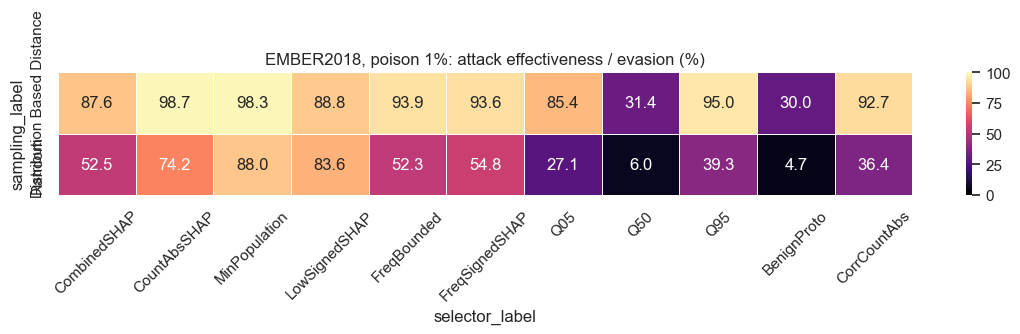

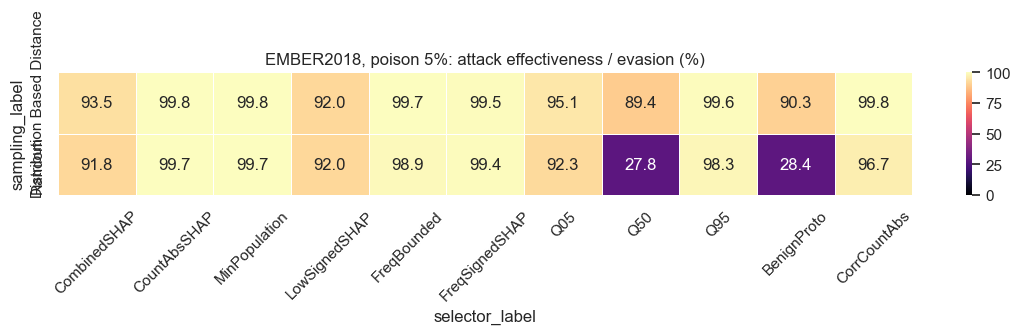

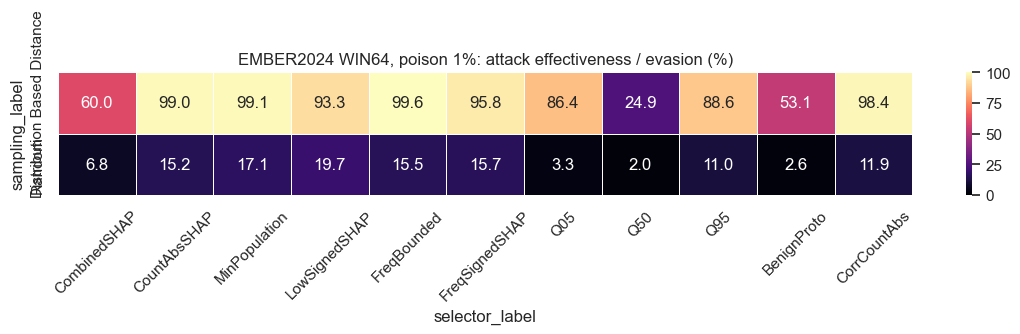

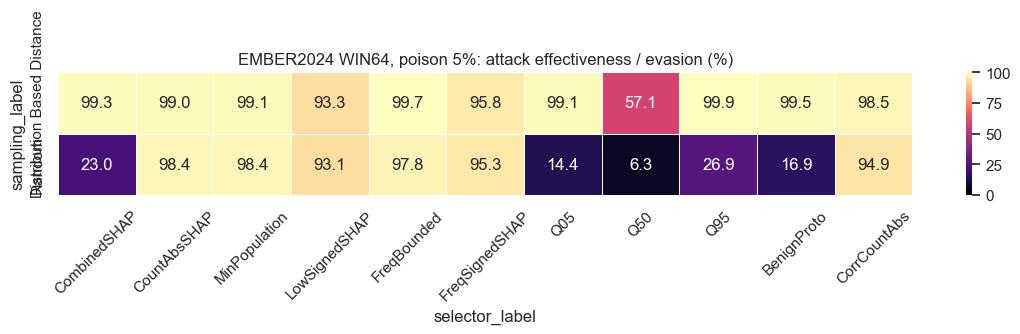

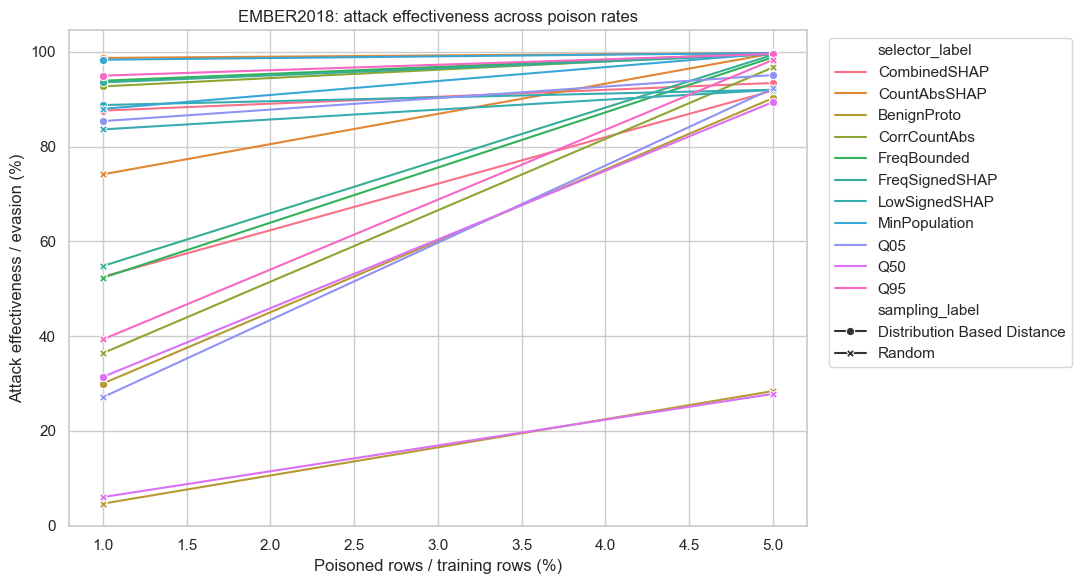

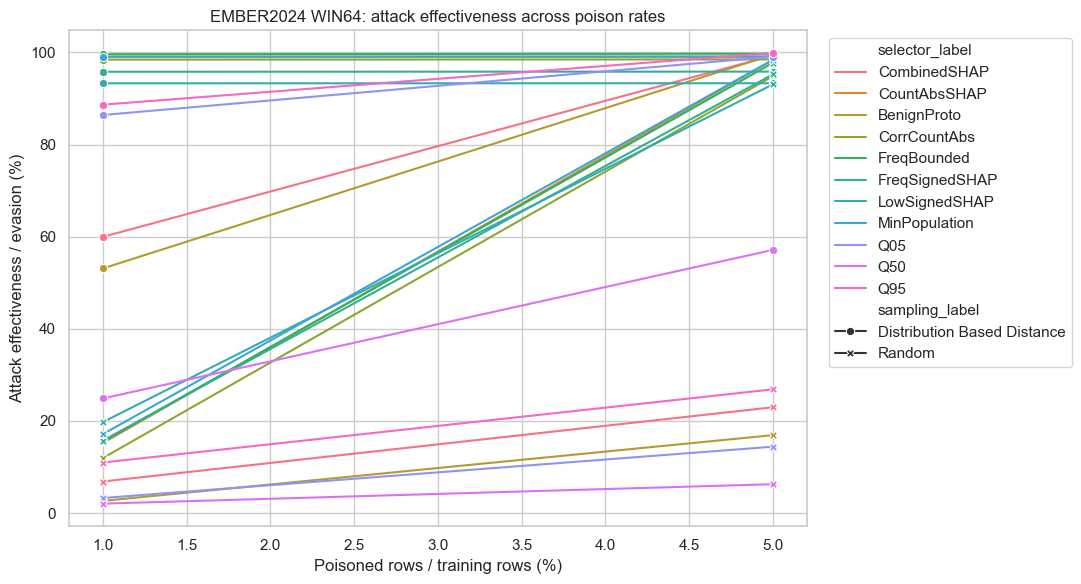

In [6]:
for (dataset, poison_label), group in attack_df.groupby(
    ["dataset_label", "poison_rate_label"], dropna=False
):
    pivot = ordered_pivot(
        group,
        index="sampling_label",
        columns="selector_label",
        values="attack_effectiveness_percent",
    )
    show_heatmap(
        pivot,
        f"{dataset}, poison {poison_label}: attack effectiveness / evasion (%)",
        cmap="magma",
        vmin=0,
        vmax=100,
    )

for dataset, group in attack_df.groupby("dataset_label"):
    fig, ax = plt.subplots(figsize=(11, 6))
    sns.lineplot(
        data=group,
        x="poison_rate_percent",
        y="attack_effectiveness_percent",
        hue="selector_label",
        style="sampling_label",
        markers=True,
        dashes=False,
        estimator="mean",
        errorbar=None,
        ax=ax,
    )
    ax.set_title(f"{dataset}: attack effectiveness across poison rates")
    ax.set_xlabel("Poisoned rows / training rows (%)")
    ax.set_ylabel("Attack effectiveness / evasion (%)")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Defense-Independent Footprint Metrics

These are artifact-level trigger footprints, not defense outcomes. Higher rarity/co-occurrence-rarity means the trigger pattern is less naturally supported by clean benign data. Higher SHAP footprint AUROC means poisoned benign rows are more separable from clean benign rows by trigger-feature SHAP concentration.


,dataset_label,poison_rate_label,sampling_strategy,selector_label,attack_effectiveness_percent,marginal_clean_frequency_median,marginal_neg_log10_frequency_sum,joint_threshold_075p_clean_frequency,joint_threshold_075p_clean_neg_log10_frequency,joint_threshold_100p_clean_frequency,joint_threshold_100p_clean_neg_log10_frequency,joint_threshold_100p_poison_only_support_ratio,shap_trigger_abs_ratio_auroc
28,EMBER2018,1%,distribution_based_distance,BenignProto,29.9898,0.7047,12.6198,0.0597,1.2242,0.0,4.7694,5.880000e+04,0.9981
32,EMBER2018,1%,distribution_based_distance,CombinedSHAP,87.6132,0.6438,11.9251,0.0955,1.0199,0.0,4.7694,5.880000e+04,0.9999
24,EMBER2018,1%,distribution_based_distance,CorrCountAbs,92.7204,0.1574,27.2537,0.0000,4.7694,0.0,4.7694,5.880000e+04,1.0000
25,EMBER2018,1%,distribution_based_distance,CountAbsSHAP,98.7288,0.0000,121.4809,0.0000,12.0000,0.0,12.0000,1.000000e+12,1.0000
29,EMBER2018,1%,distribution_based_distance,FreqBounded,93.9155,0.0009,70.0856,0.0000,12.0000,0.0,12.0000,1.000000e+12,1.0000
27,EMBER2018,1%,distribution_based_distance,FreqSignedSHAP,93.5713,0.0056,37.9743,0.0000,12.0000,0.0,12.0000,1.000000e+12,1.0000
31,EMBER2018,1%,distribution_based_distance,LowSignedSHAP,88.7867,0.0002,56.1784,0.0000,12.0000,0.0,12.0000,1.000000e+12,1.0000
30,EMBER2018,1%,distribution_based_distance,MinPopulation,98.3497,0.0000,117.2325,0.0000,12.0000,0.0,12.0000,1.000000e+12,1.0000
22,EMBER2018,1%,distribution_based_distance,Q05,85.3935,0.6438,21.1523,0.0809,1.0920,0.0,12.0000,1.000000e+12,0.9995
23,EMBER2018,1%,distribution_based_distance,Q50,31.4007,0.7047,20.4900,0.0830,1.0810,0.0,12.0000,1.000000e+12,0.9997


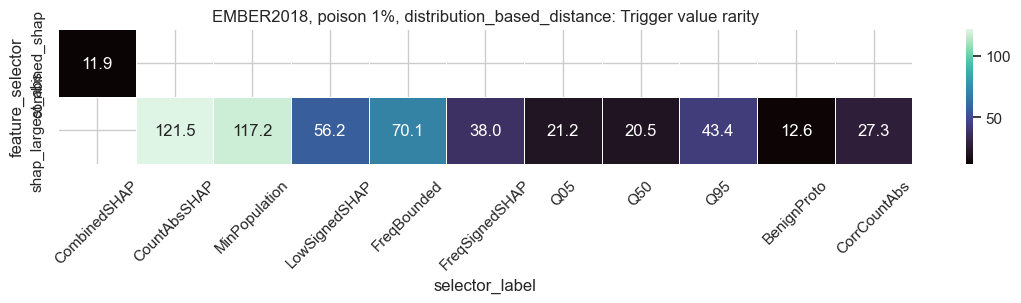

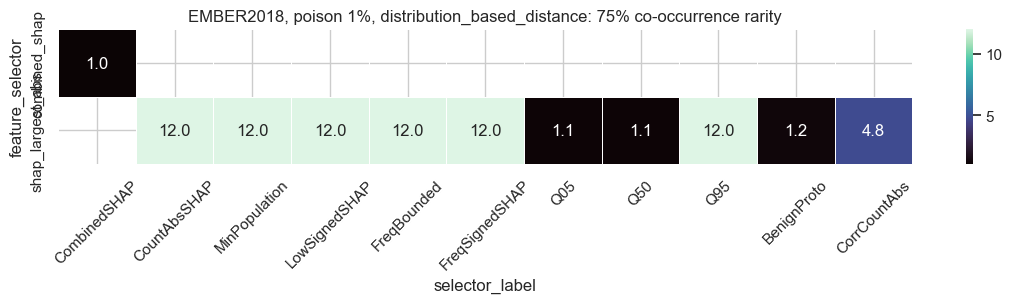

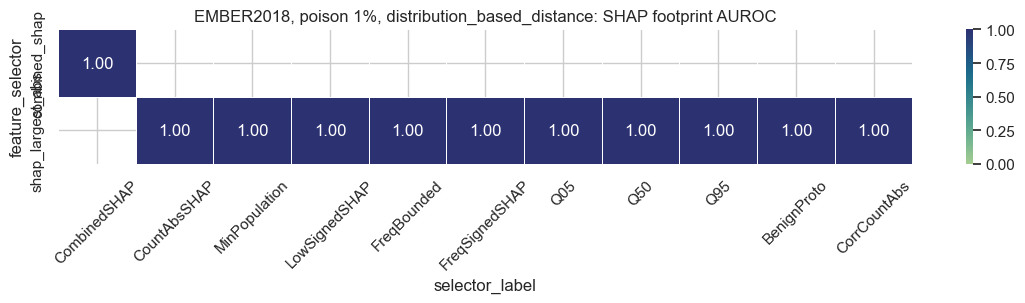

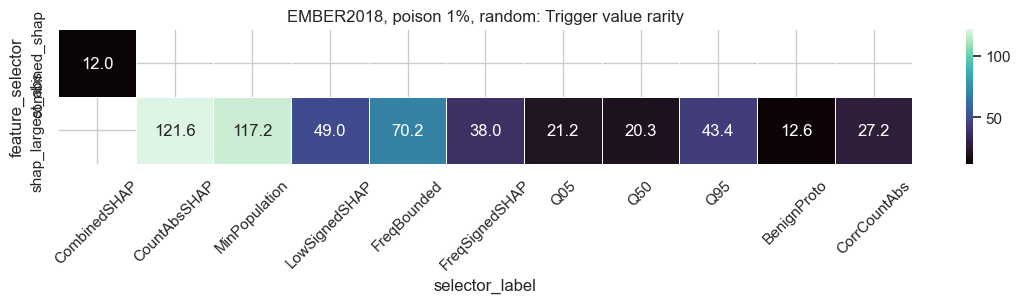

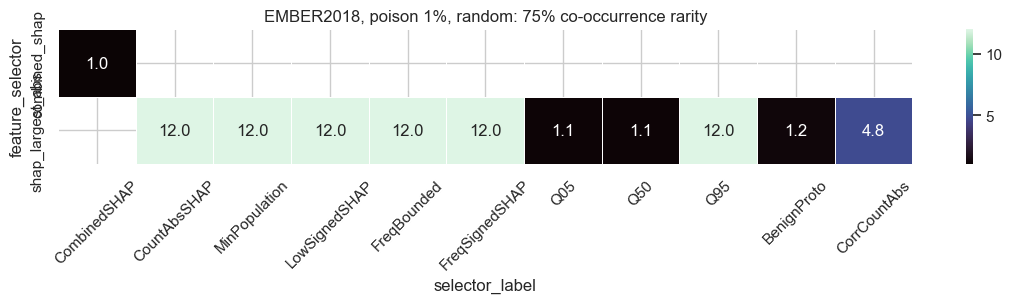

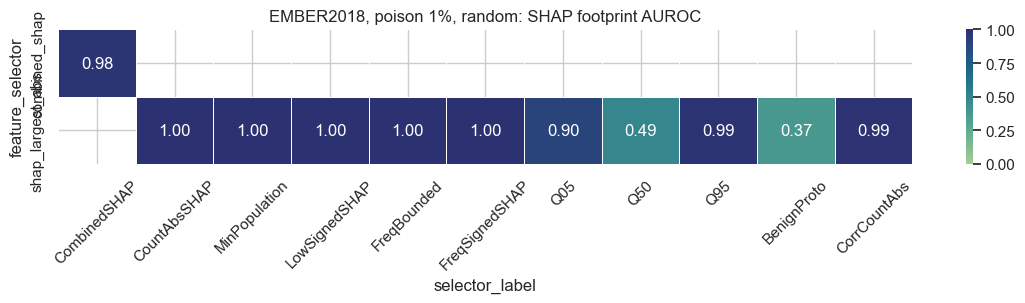

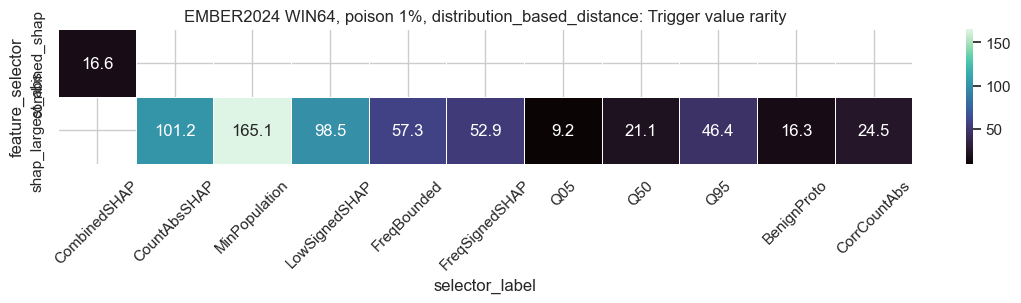

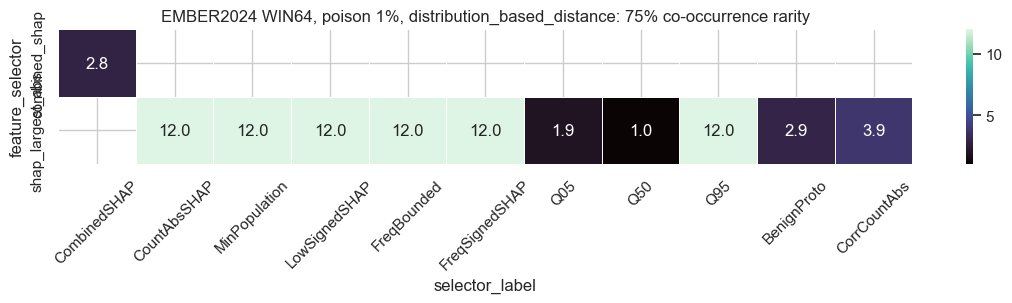

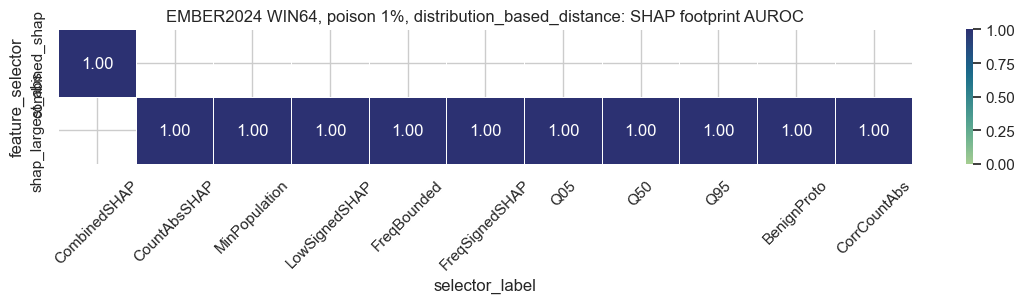

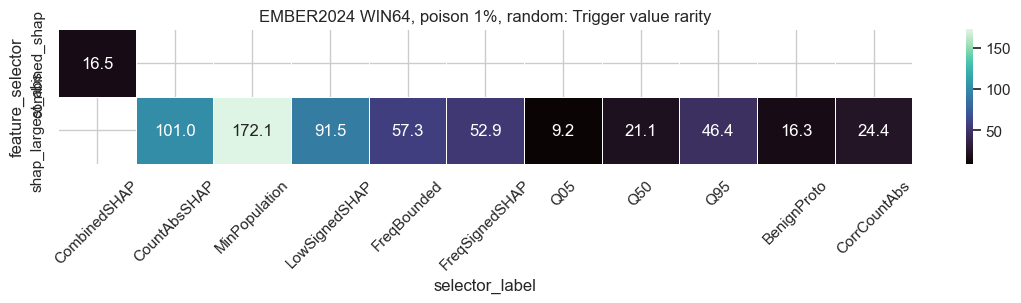

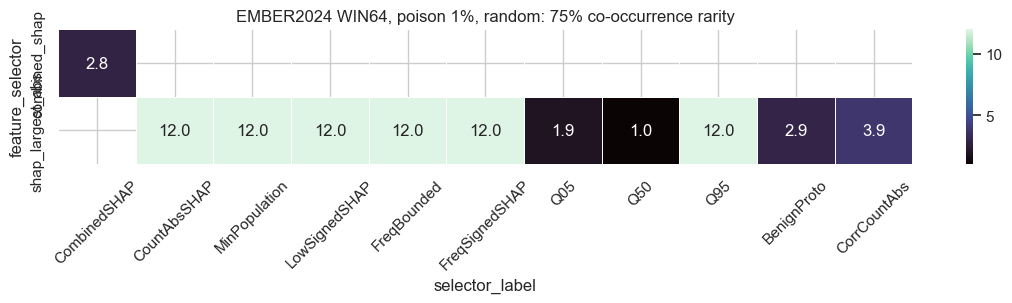

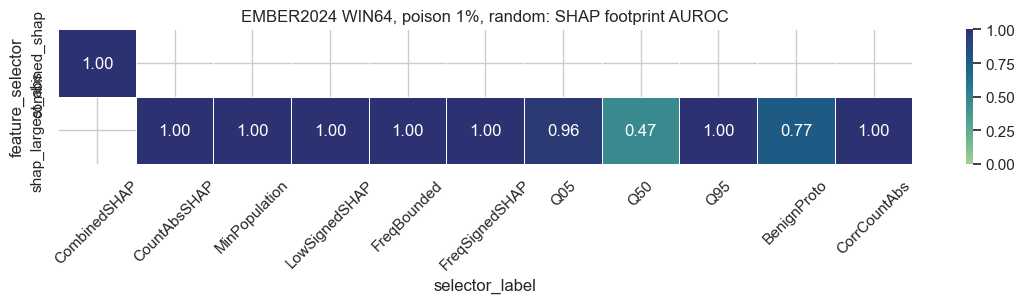

In [7]:
footprint_metrics = [
    ("marginal_neg_log10_frequency_sum", "Trigger value rarity", "mako", ".1f"),
    ("joint_threshold_075p_clean_neg_log10_frequency", "75% co-occurrence rarity", "mako", ".1f"),
    ("shap_trigger_abs_ratio_auroc", "SHAP footprint AUROC", "crest", ".2f"),
]
detectability_metrics = footprint_metrics

footprint_table_cols = [
    "dataset_label",
    "poison_rate_label",
    "sampling_strategy",
    "selector_label",
    "attack_effectiveness_percent",
    "marginal_clean_frequency_median",
    "marginal_neg_log10_frequency_sum",
    "joint_threshold_075p_clean_frequency",
    "joint_threshold_075p_clean_neg_log10_frequency",
    "joint_threshold_100p_clean_frequency",
    "joint_threshold_100p_clean_neg_log10_frequency",
    "joint_threshold_100p_poison_only_support_ratio",
    "shap_trigger_abs_ratio_auroc",
]
available_footprint_cols = [col for col in footprint_table_cols if col in merged_df.columns]
if merged_df.empty or not available_footprint_cols:
    print("No footprint diagnostics available yet.")
else:
    display(
        merged_df[available_footprint_cols]
        .sort_values(["dataset_label", "poison_rate_label", "sampling_strategy", "selector_label"])
        .round(4)
    )

for (dataset, poison_label, sampling), group in diagnostic_df.groupby(
    ["dataset_label", "poison_rate_label", "sampling_strategy"], dropna=False
):
    for metric, title, cmap, fmt in footprint_metrics:
        if metric not in group or group[metric].notna().sum() == 0:
            continue
        pivot = ordered_pivot(
            group,
            index="feature_selector",
            columns="selector_label",
            values=metric,
        )
        show_heatmap(
            pivot,
            f"{dataset}, poison {poison_label}, {sampling}: {title}",
            cmap=cmap,
            fmt=fmt,
            vmin=0 if "auroc" in metric else None,
            vmax=1 if "auroc" in metric else None,
        )


## Effectiveness Versus Footprint Detectability


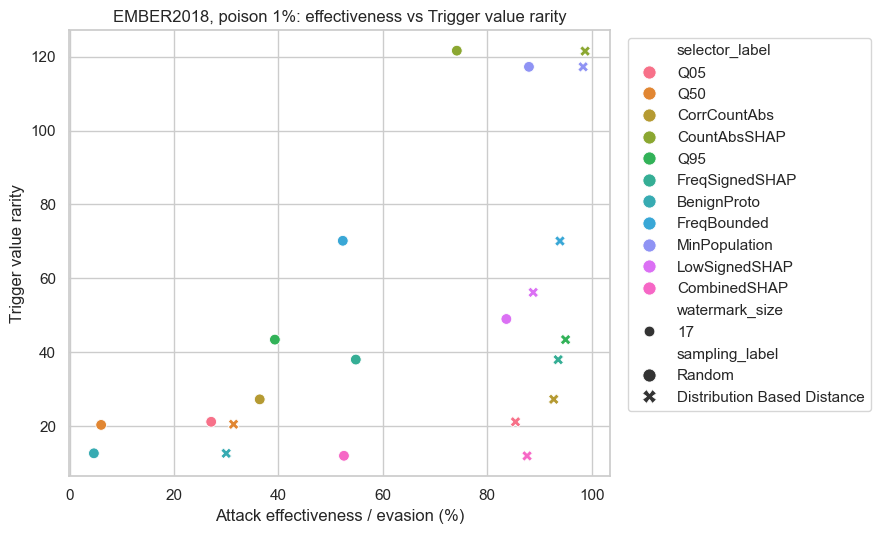

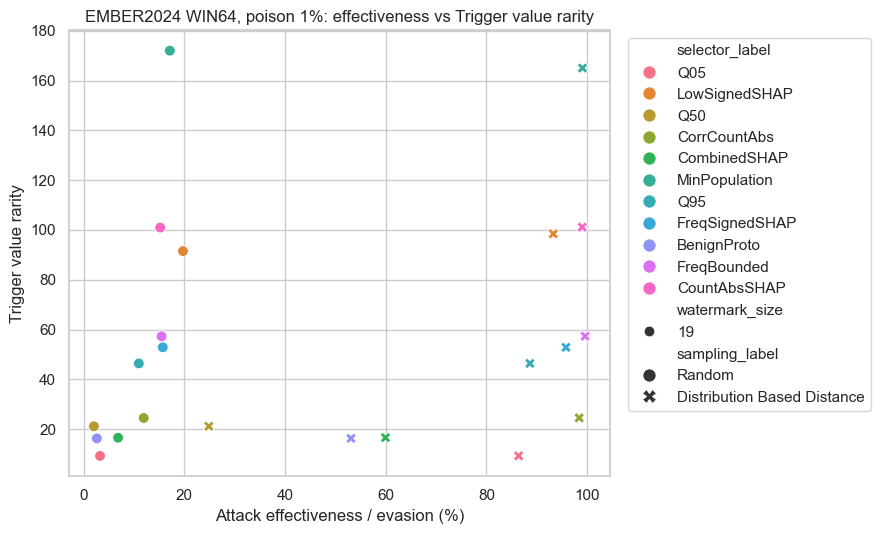

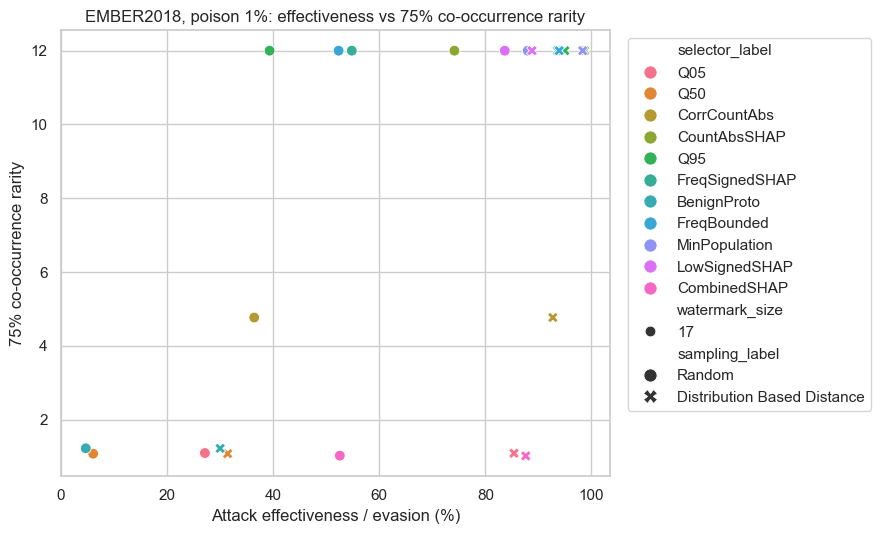

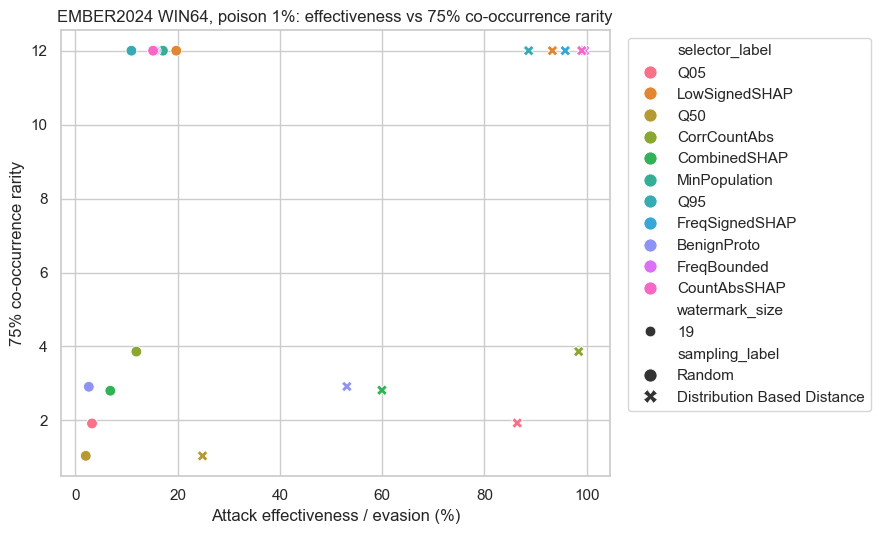

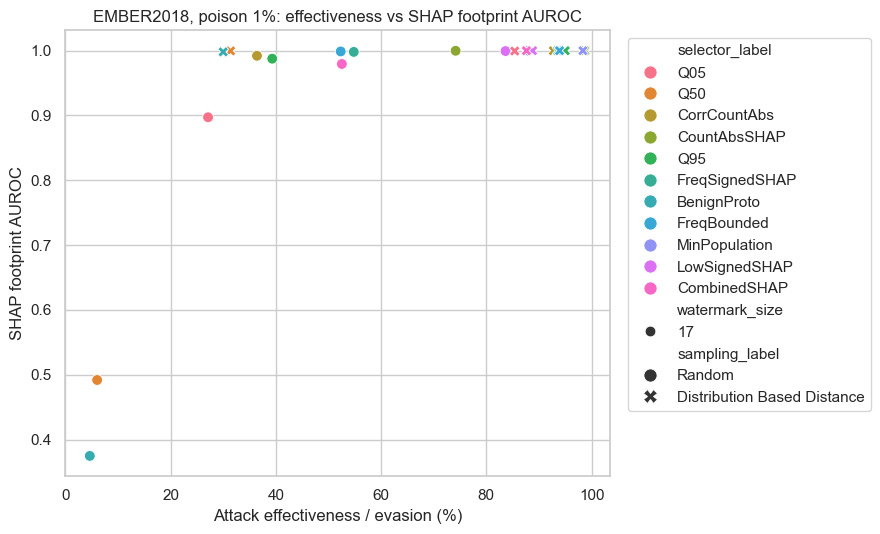

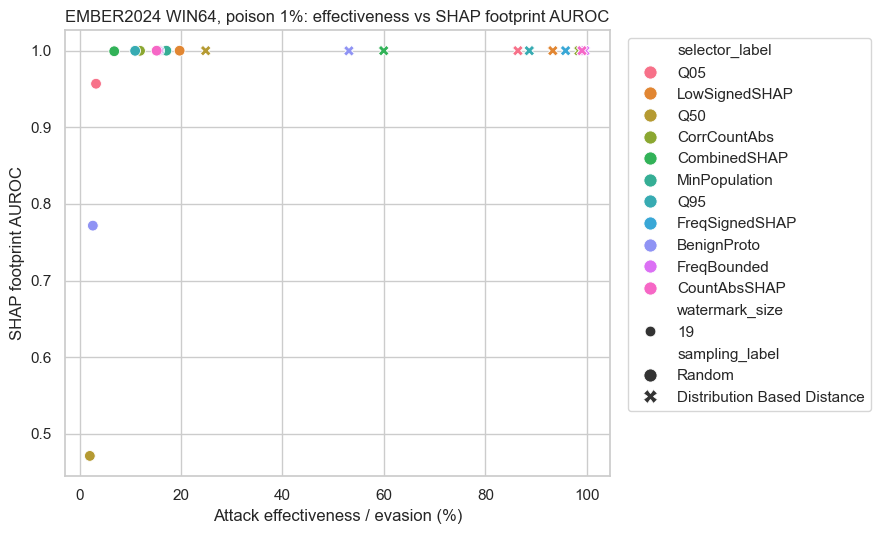

In [8]:
for metric, metric_title, _, _ in detectability_metrics:
    if merged_df.empty or metric not in merged_df:
        continue
    focus = merged_df.dropna(subset=["attack_effectiveness_percent", metric]).copy()
    if focus.empty:
        continue
    for (dataset, poison_label), group in focus.groupby(
        ["dataset_label", "poison_rate_label"], dropna=False
    ):
        fig, ax = plt.subplots(figsize=(9, 5.5))
        sns.scatterplot(
            data=group,
            x="attack_effectiveness_percent",
            y=metric,
            hue="selector_label",
            style="sampling_label",
            size="watermark_size",
            sizes=(60, 180),
            s=90,
            ax=ax,
        )
        ax.set_title(
            f"{dataset}, poison {poison_label}: effectiveness vs {metric_title}"
        )
        ax.set_xlabel("Attack effectiveness / evasion (%)")
        ax.set_ylabel(metric_title)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

## Poison-Rate Detectability Comparison

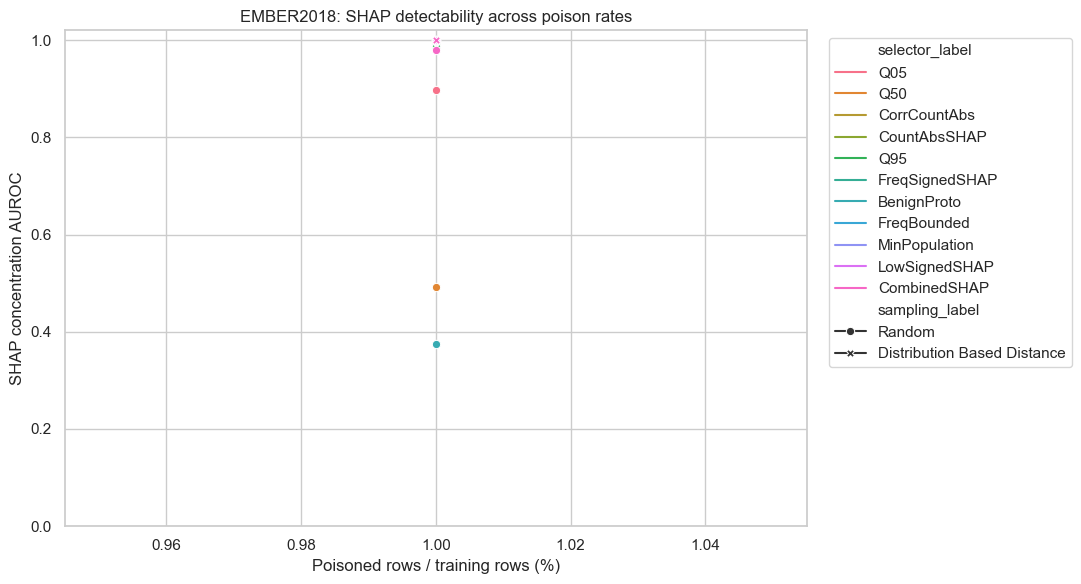

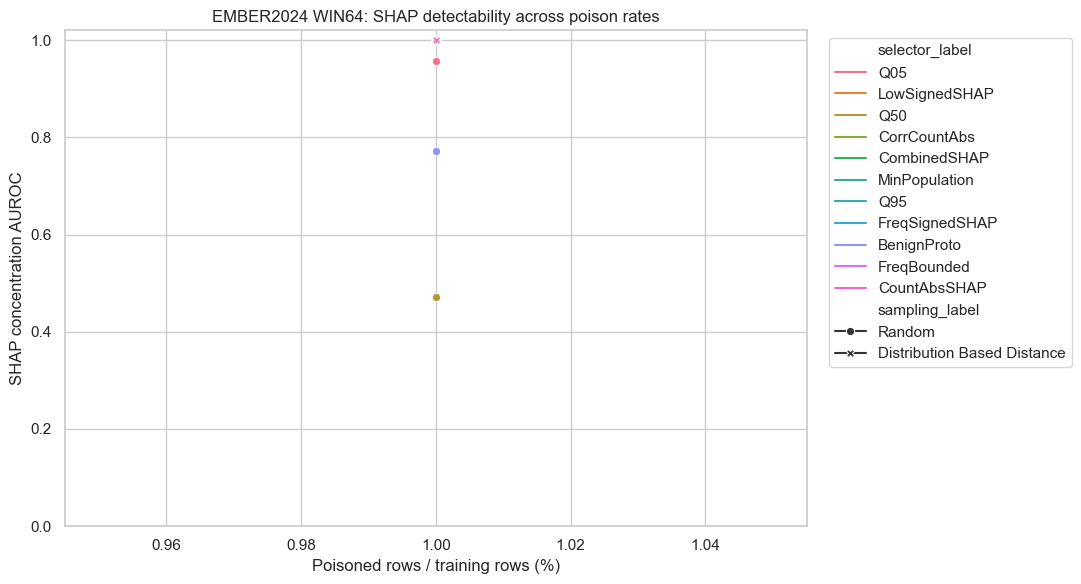

In [9]:
if diagnostic_df.empty:
    print("No diagnostics available for poison-rate comparison.")
else:
    metric = "shap_trigger_abs_ratio_auroc"
    focus = diagnostic_df.dropna(subset=[metric]).copy()
    for dataset, group in focus.groupby("dataset_label"):
        fig, ax = plt.subplots(figsize=(11, 6))
        sns.lineplot(
            data=group,
            x="poison_rate_percent",
            y=metric,
            hue="selector_label",
            style="sampling_label",
            markers=True,
            dashes=False,
            estimator="mean",
            errorbar=None,
            ax=ax,
        )
        ax.set_title(f"{dataset}: SHAP detectability across poison rates")
        ax.set_xlabel("Poisoned rows / training rows (%)")
        ax.set_ylabel("SHAP concentration AUROC")
        ax.set_ylim(0, 1.02)
        ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

## Recall At A Suspicion Budget

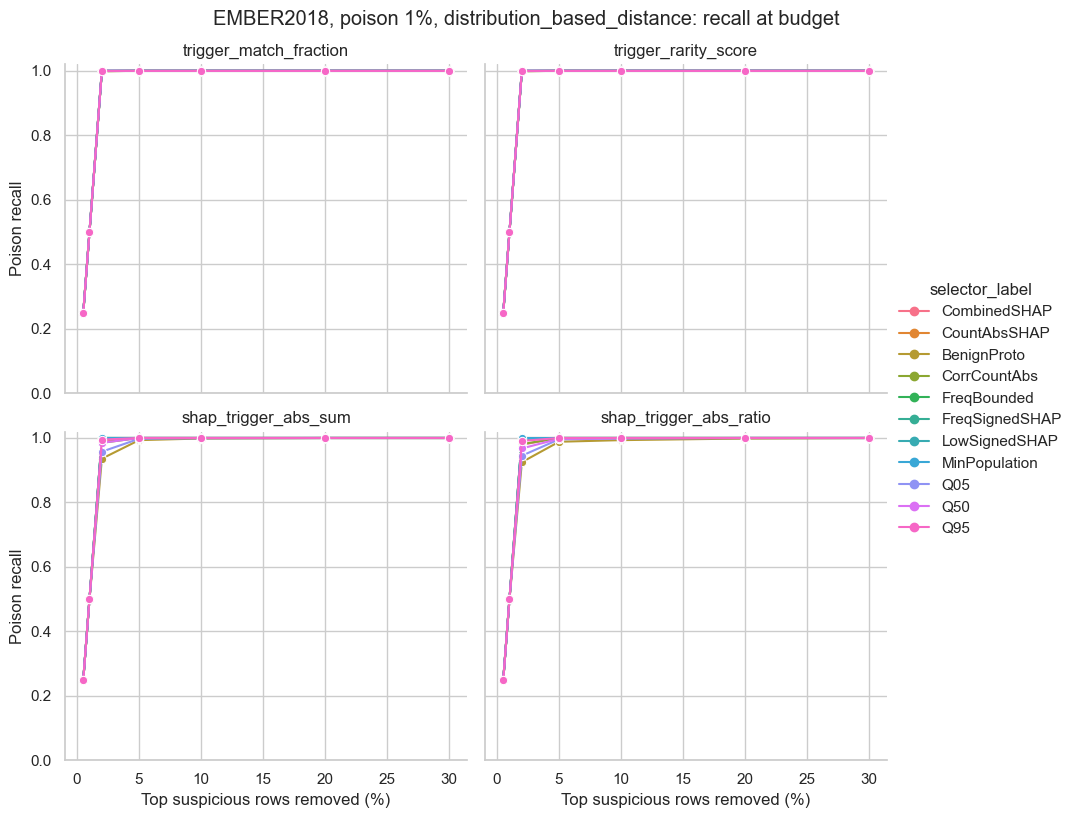

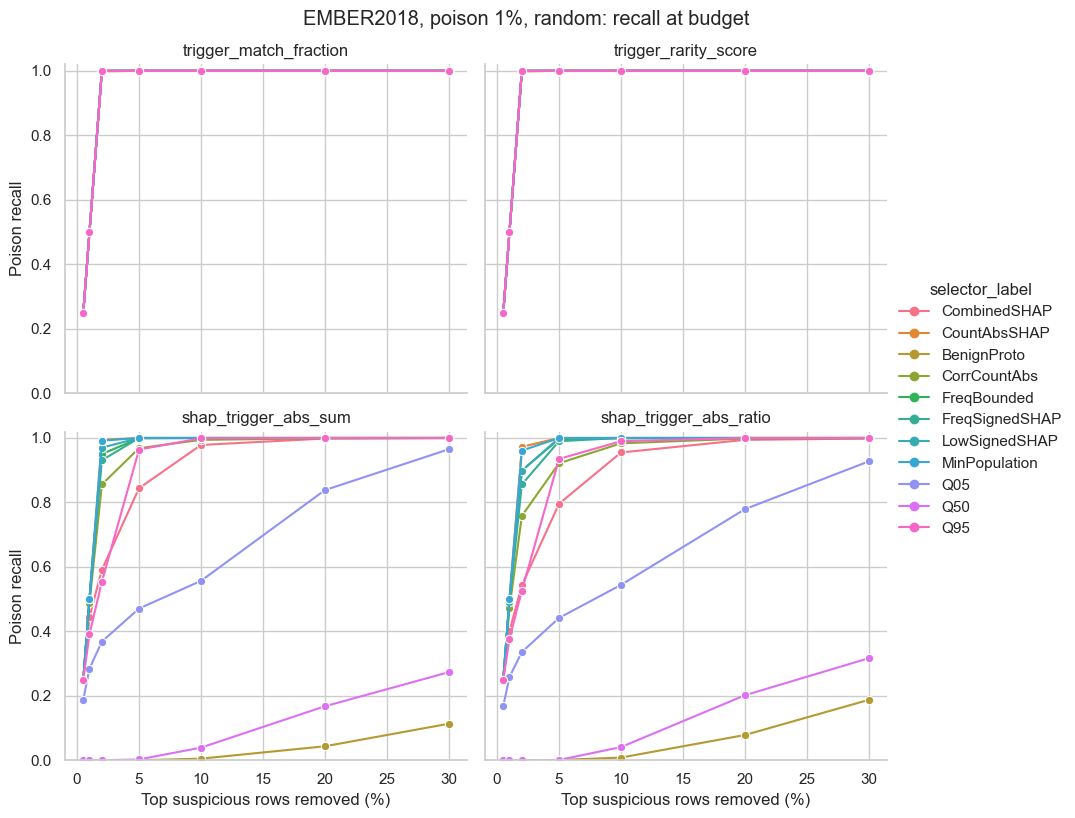

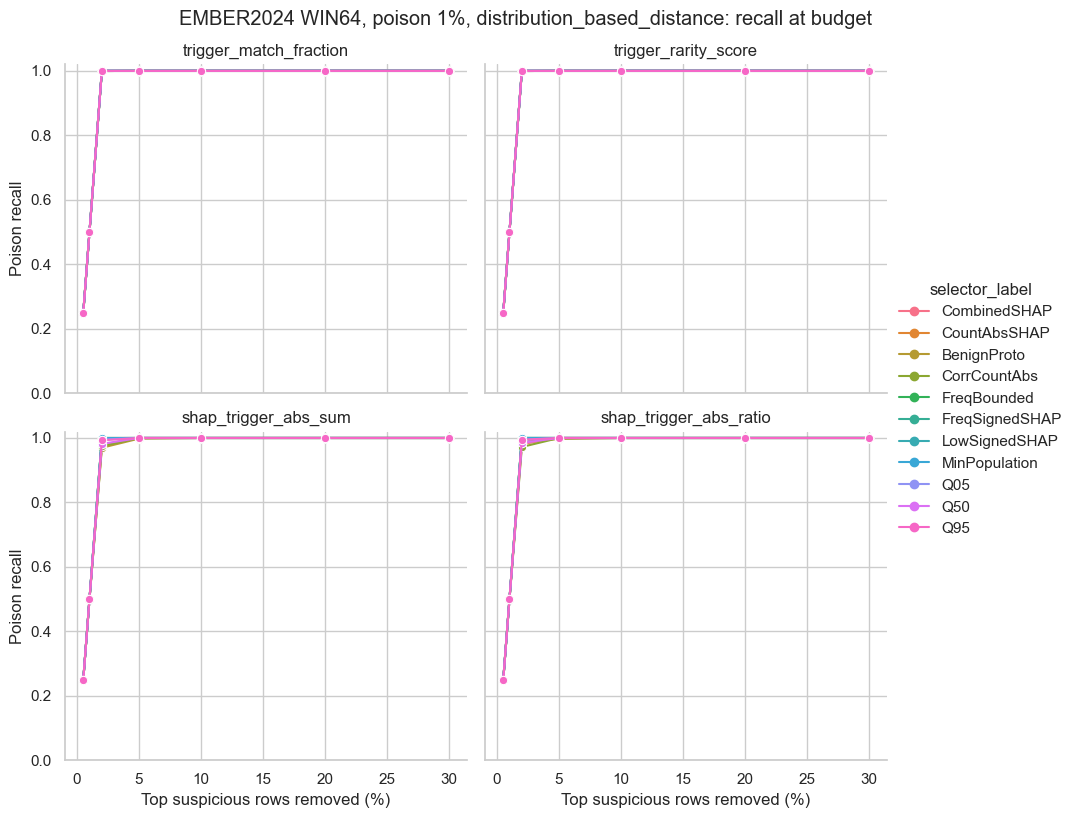

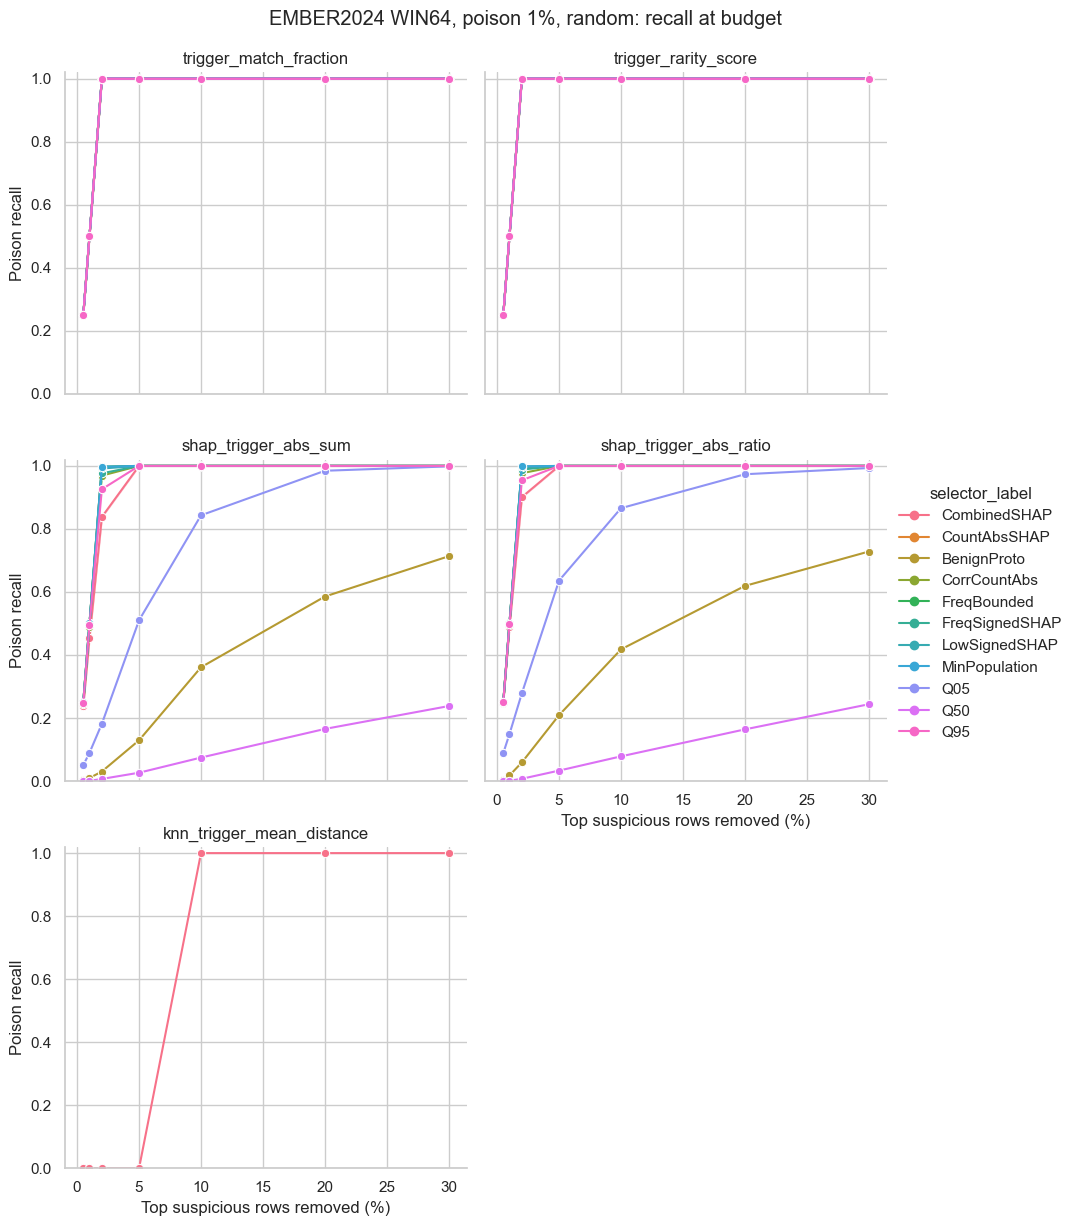

In [10]:
if score_df.empty:
    print("No detectability score metrics available.")
else:
    for (dataset, poison_label, sampling), group in score_df.groupby(
        ["dataset_label", "poison_rate_label", "sampling_strategy"], dropna=False
    ):
        g = sns.relplot(
            data=group,
            x="top_percent",
            y="poison_recall",
            hue="selector_label",
            col="score_name",
            col_wrap=2,
            kind="line",
            marker="o",
            facet_kws={"sharex": True, "sharey": True},
            height=4,
            aspect=1.15,
        )
        g.set_axis_labels("Top suspicious rows removed (%)", "Poison recall")
        g.set_titles("{col_name}")
        g.fig.suptitle(
            f"{dataset}, poison {poison_label}, {sampling}: recall at budget",
            y=1.02,
        )
        for ax in g.axes.flat:
            ax.set_ylim(0, 1.02)
        plt.show()

## Optional Export

In [11]:
SAVE_TABLES = False
if SAVE_TABLES:
    out_dir = RESULTS_ROOT / "tables"
    out_dir.mkdir(parents=True, exist_ok=True)
    attack_df.to_csv(out_dir / "paper_attack_effectiveness_for_detectability.csv", index=False)
    diagnostic_df.to_csv(out_dir / "paper_detectability_catalog.csv", index=False)
    merged_df.to_csv(out_dir / "paper_effectiveness_vs_detectability.csv", index=False)
    missing_diagnostics.to_csv(out_dir / "paper_missing_detectability_runs.csv", index=False)
    print("Saved tables to", out_dir)
else:
    print("SAVE_TABLES is False; no files written.")

SAVE_TABLES is False; no files written.
